# Hackathon Demo: Optimization Layer Metrics Analysis

This notebook analyzes the `logs/results.csv` data generated by running our unoptimized baseline (direct prompts to LLMs) alongside our intelligent Edge Optimization Engine (telemetry-guided parameter adjusting).

The metrics show differences in CPU usages, RAM consumed, inference latency, and hardware efficiency by plotting dynamic heatmaps and comparison graphs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1A1A1A", "figure.facecolor": "#1A1A1A", "grid.color": "#333333"})

# Load resulting CSV logs
df = pd.read_csv("logs/results.csv")
df.head()

,Model,NumCtx,NumPredict,Latency(s),CPU(%),RAM(%),Tokens/sec,EfficiencyScore,Mode
0,llama3.2:latest,4096,1000,14.72,2.9,63.0,10.74,2.75,Unoptimized
1,llama3.2:latest,4096,1000,19.09,13.0,79.2,14.20,1.01,Unoptimized
2,llama3.2:latest,4096,1000,22.96,11.8,76.1,14.29,1.11,Unoptimized
3,phi3:mini,256,200,17.00,17.4,76.6,9.06,7.87,Optimized
4,phi3:mini,256,200,17.52,14.3,84.7,11.42,11.94,Optimized


### 1. CPU and RAM Resource Usage Comparison
How much does our engine save system load?

C:\Users\mv143\AppData\Local\Temp\ipykernel_18968\1465707044.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Mode", y="CPU(%)", palette="viridis", ax=axes[0])
C:\Users\mv143\AppData\Local\Temp\ipykernel_18968\1465707044.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Mode", y="RAM(%)", palette="coolwarm", ax=axes[1])


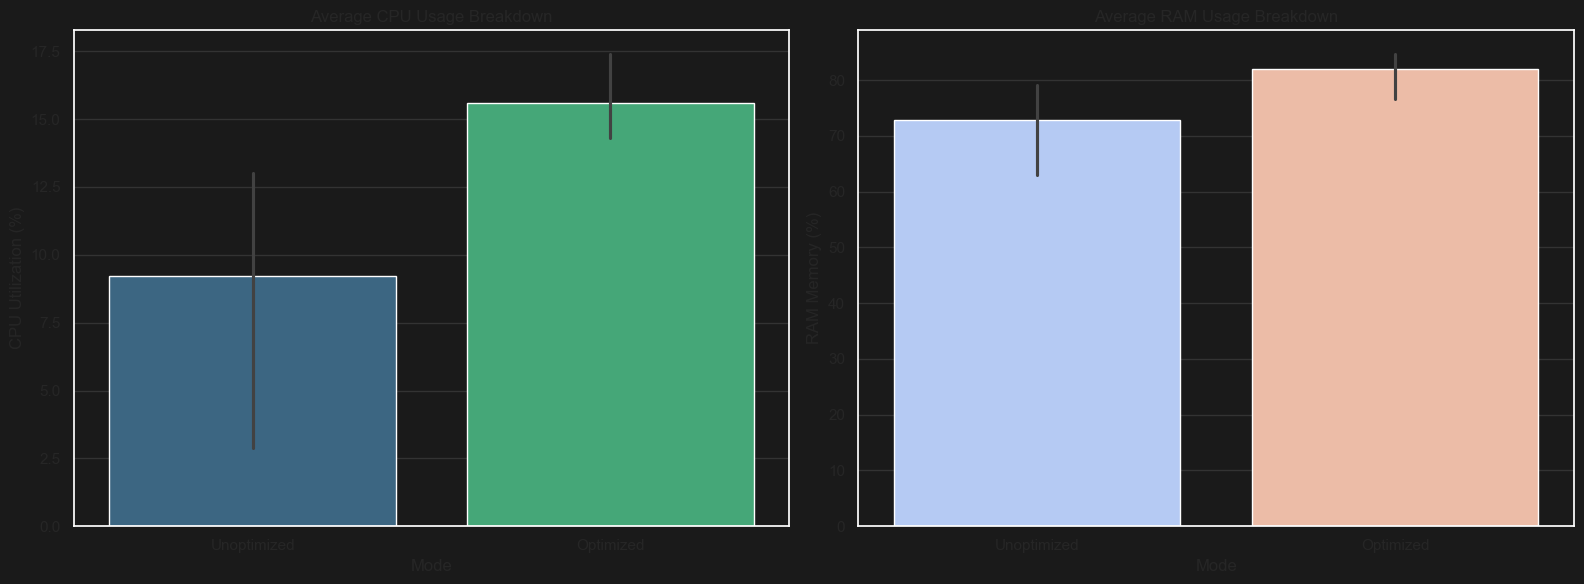

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CPU Comparison
sns.barplot(data=df, x="Mode", y="CPU(%)", palette="viridis", ax=axes[0])
axes[0].set_title("Average CPU Usage Breakdown")
axes[0].set_ylabel("CPU Utilization (%)")

# RAM Comparison
sns.barplot(data=df, x="Mode", y="RAM(%)", palette="coolwarm", ax=axes[1])
axes[1].set_title("Average RAM Usage Breakdown")
axes[1].set_ylabel("RAM Memory (%)")

plt.tight_layout()
plt.show()

### 2. Efficiency Score & Token Throughput Metrics
Efficiency score is measured dynamically by our engine as `Tokens Generated / (CPU Usage + 1)`.

C:\Users\mv143\AppData\Local\Temp\ipykernel_18968\612482032.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Mode", y="Tokens/sec", palette="Set2", ax=axes[1])


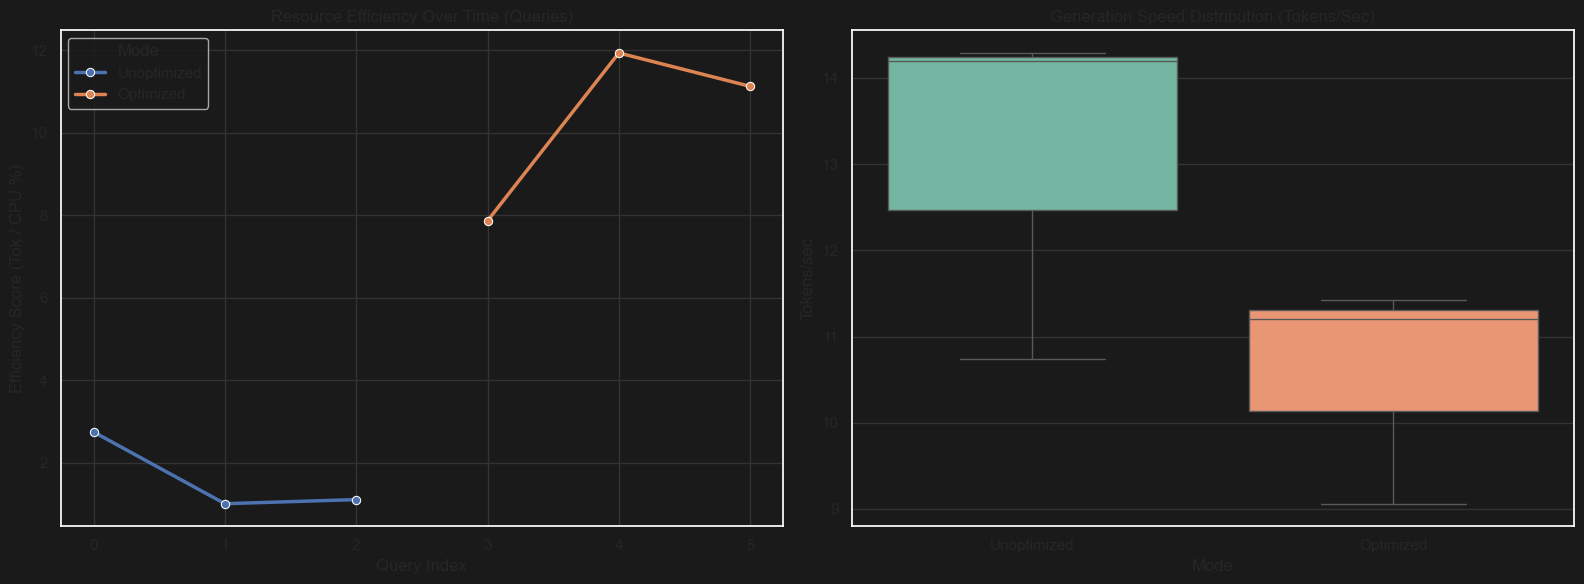

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=df, x=df.index, y="EfficiencyScore", hue="Mode", marker="o", linewidth=2.5, ax=axes[0])
axes[0].set_title("Resource Efficiency Over Time (Queries)")
axes[0].set_xlabel("Query Index")
axes[0].set_ylabel("Efficiency Score (Tok / CPU %)")

sns.boxplot(data=df, x="Mode", y="Tokens/sec", palette="Set2", ax=axes[1])
axes[1].set_title("Generation Speed Distribution (Tokens/Sec)")

plt.tight_layout()
plt.show()

### 3. Layer System Telemetry Heatmap
Visualizing the correlation matrices inside unoptimized and optimized instances.

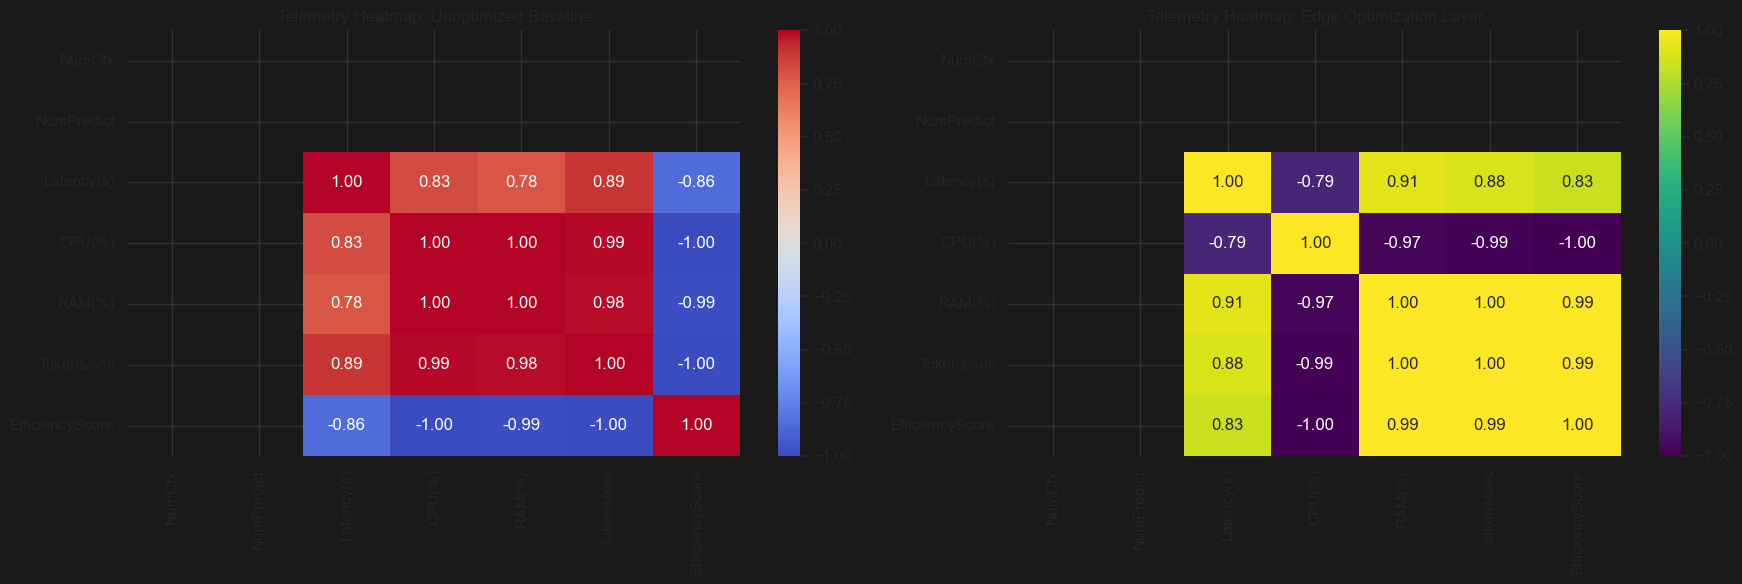

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

numeric_cols = ["NumCtx", "NumPredict", "Latency(s)", "CPU(%)", "RAM(%)", "Tokens/sec", "EfficiencyScore"]

optim_corr = df[df['Mode'] == 'Optimized'][numeric_cols].corr()
unoptim_corr = df[df['Mode'] == 'Unoptimized'][numeric_cols].corr()

sns.heatmap(unoptim_corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Telemetry Heatmap: Unoptimized Baseline")

sns.heatmap(optim_corr, annot=True, cmap="viridis", fmt=".2f", ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Telemetry Heatmap: Edge Optimization Layer")

plt.tight_layout()
plt.show()

### 4. Dynamic Generation Parameter Adaptation
The layer automatically limits `Context Window (NumCtx)` down based on limits while preserving maximum output capability.

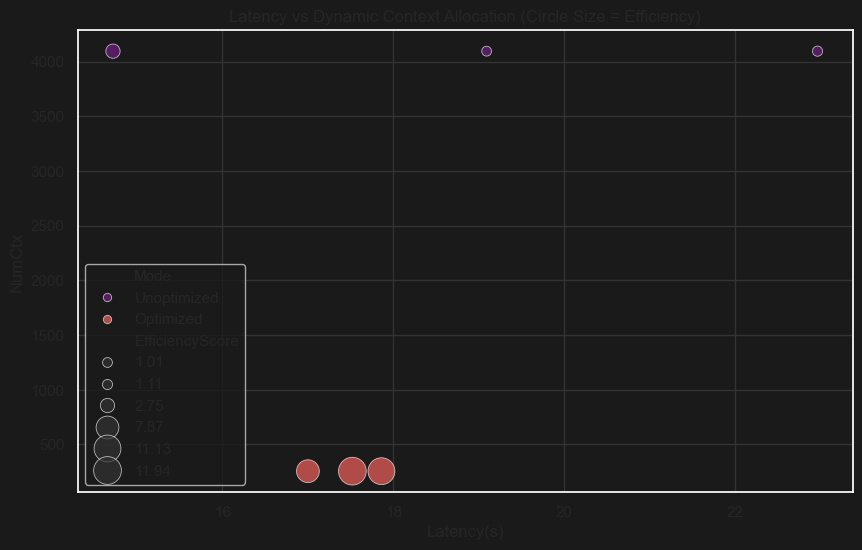

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Latency(s)", y="NumCtx", hue="Mode", size="EfficiencyScore", sizes=(50, 400), alpha=0.7, palette="magma")
plt.title("Latency vs Dynamic Context Allocation (Circle Size = Efficiency)")
plt.show()